In [1]:
"""
multiclass_parallel.py

Sequential parallel:
          ┌─→ LSTM branch ──┐
Input →───┤                  ├→ [concat] → Classifier (Softmax / Gated)
          └─→ CNN branch ───┘


Evaluates for splits: 60/40, 70/30, 80/20
"""

import time
import psutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,                  # <-- ADDED for F1 (macro) later
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler  # <-- ADDED

from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN  # <-- ADDED ADASYN, merged SMOTE import
from imblearn.under_sampling import TomekLinks                    # <-- ADDED for ADASYN+Tomek

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import random
import os

# =============== GLOBAL TOGGLES (YOU WILL ONLY CHANGE THESE) ===============
# SCALER_NAME options: "minmax", "robust", "standard"
SCALER_NAME = "minmax"

# CLASSIFIER_TYPE options: "softmax", "gated"
CLASSIFIER_TYPE = "softmax"

# IMB_METHOD options:
#   "smote", "smote_borderline", "adasyn", "adasyn_tomek", "none"
IMB_METHOD = "smote"
# ========================================================================


In [2]:
# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [3]:

# ---------------------------
# User: load your DataFrame here
# Replace this with pd.read_csv(...) or pass your df
# ---------------------------
# Example: df = pd.read_csv("your_data.csv")
# For demonstration, I will assume `df` already exists in the environment.
# The user provided a DataFrame description. If you run this as a script,
# replace the line below with: df = pd.read_csv("path_to_csv.csv")
try:
    df = pd.read_csv("all_three.csv")
except NameError:
    raise RuntimeError("Please set `df` to your pandas DataFrame before running this script (e.g., df = pd.read_csv(...)).")


In [4]:
# ---------------------------
# Basic checks & feature selection
# ---------------------------
TARGET_COL = "label"
if TARGET_COL not in df.columns:
    raise RuntimeError(f"Target column '{TARGET_COL}' not found in DataFrame.")

# Drop any non-feature columns you don't want (like Unnamed: 0, block_id etc.) OR keep them if meaningful.
# Here we'll drop 'Unnamed: 0' if present (index column)
drop_cols = []
for c in ["Unnamed: 0"]:
    if c in df.columns:
        drop_cols.append(c)

# Use all numeric features except the target
X_cols = [c for c in df.columns if c != TARGET_COL and c not in drop_cols]
X = df[X_cols].values.astype(np.float32)
y = df[TARGET_COL].values.astype(np.int64)

# Ensure labels are 0..3
unique_labels = np.unique(y)
expected = set([0,1,2,3])
if not set(unique_labels).issubset(expected):
    print(f"Warning: labels found = {unique_labels}. Remapping to 0..3 if possible.")
    # Simple remap if labels are e.g., [1,2,3,4] -> [0,1,2,3]
    min_label = unique_labels.min()
    if set(unique_labels) == set(range(min_label, min_label + 4)):
        y = y - min_label
    else:
        raise RuntimeError("Labels are not in expected 0..3 range and can't auto-remap. Please fix labels.")

print("Feature shape:", X.shape, "Label counts:", pd.Series(y).value_counts().to_dict())


Feature shape: (427625, 23) Label counts: {0: 335847, 2: 55390, 3: 34134, 1: 2254}


In [5]:
# ---------------------------
# Decimal-scaling Normalizer
# ---------------------------
class DecimalScaler:
    """
    Decimal scaling normalization: divide each feature by 10^ceil(log10(max_abs)))
    Fit on train only.
    """
    def __init__(self):
        self.den = None

    def fit(self, X):
        max_abs = np.max(np.abs(X), axis=0)
        # avoid log10(0) issues
        max_abs_safe = np.where(max_abs == 0, 1.0, max_abs)
        self.den = np.power(10.0, np.ceil(np.log10(max_abs_safe)))
        return self

    def transform(self, X):
        if self.den is None:
            raise RuntimeError("DecimalScaler not fitted.")
        return X / self.den

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


In [6]:
# ---------------------------
# Dataset wrapper and helpers
# ---------------------------
def tabular_to_sequence(X_array):
    """
    Convert a tabular row of shape (n_features,) -> sequence shape (seq_len=n_features, features=1)
    We'll feed LSTM with input_size=1 and seq_len = n_features
    """
    # returns shape (n_samples, seq_len, 1)
    return X_array.reshape((X_array.shape[0], X_array.shape[1], 1))

class TabularSequenceDataset(Dataset):
    def __init__(self, X_seq, y):
        # X_seq: (N, seq_len, 1)
        self.X = torch.tensor(X_seq, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [7]:
# ---------------------------
# Models
# ---------------------------
class LSTMEncoder(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, bidirectional=False, dropout=0.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_directions = 2 if bidirectional else 1
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True,
                            bidirectional=bidirectional, dropout=dropout)

    def forward(self, x):
        # x: (B, seq_len, input_size)
        out, (hn, cn) = self.lstm(x)  # out: (B, seq_len, hidden_size * num_directions)
        # We'll use last time-step output
        # If bidirectional, concatenate last forward and backward hidden:
        if self.num_directions == 1:
            # take the last output (from out)
            emb = out[:, -1, :]  # (B, hidden_size)
        else:
            # hn shape: (num_layers*2, B, hidden_size)
            # take last layer both directions
            h_forward = hn[-2,:,:]
            h_backward = hn[-1,:,:]
            emb = torch.cat([h_forward, h_backward], dim=1)
        return emb  # (B, emb_dim)


In [8]:
class CNNClassifier(nn.Module):
    """
    Simple 1D-CNN classifier that accepts (B, C=1, L=embedding_dim)
    """
    def __init__(self, emb_dim, num_classes=4):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)  # collapse length
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        # x: (B, 1, L)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)  # (B, 64, 1)
        x = x.view(x.size(0), -1)  # (B, 64)
        logits = self.fc(x)  # (B, num_classes)
        return logits


In [9]:
class ParallelCNNLSTM(nn.Module):
    """
    Parallel CNN + LSTM:
    - LSTM branch: (B, seq_len, 1)
    - CNN branch: (B, 1, seq_len)
    - Fused by concatenation -> classifier (softmax / gated)
    """
    def __init__(self, lstm_hidden=64, num_classes=4, classifier_type="softmax"):
        super().__init__()

        # ----- LSTM branch -----
        self.lstm = LSTMEncoder(
            input_size=1,
            hidden_size=lstm_hidden,
            num_layers=1,
            bidirectional=False
        )

        # ----- CNN branch -----
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool  = nn.AdaptiveAvgPool1d(1)  # -> (B, 64, 1)

        # Fused feature dim = LSTM_hidden + 64
        fused_dim = lstm_hidden + 64
        self.fc = nn.Linear(fused_dim, num_classes)

        # classifier_type: "softmax" or "gated"
        self.classifier_type = classifier_type.lower()
        if self.classifier_type == "gated":
            self.gate_fc = nn.Linear(num_classes, num_classes)

    def forward(self, x, A_norm=None):
        # x: (B, seq_len, 1)

        # ----- LSTM branch -----
        emb_lstm = self.lstm(x)  # (B, lstm_hidden)

        # ----- CNN branch -----
        x_cnn = x.transpose(1, 2)      # (B, 1, seq_len)
        x_cnn = F.relu(self.conv1(x_cnn))
        x_cnn = F.relu(self.conv2(x_cnn))
        x_cnn = self.pool(x_cnn)       # (B, 64, 1)
        x_cnn = x_cnn.view(x_cnn.size(0), -1)  # (B, 64)

        # ----- Fusion -----
        fused = torch.cat([emb_lstm, x_cnn], dim=1)  # (B, lstm_hidden + 64)
        logits = self.fc(fused)                      # (B, num_classes)

        # Optional gated head
        if self.classifier_type == "gated":
            gate = torch.sigmoid(self.gate_fc(logits))  # (B, num_classes)
            logits = logits * gate

        return logits, emb_lstm


In [10]:
# ---------------------------
# Training & Evaluation functions
# ---------------------------
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)    # (B, seq_len, 1)
        y_batch = y_batch.to(device)

        # GNN + kNN adjacency removed: model is now pure CNN + LSTM
        optimizer.zero_grad()
        logits, _ = model(X_batch)      # (B, num_classes), emb (unused here)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_model(model, loader, device):
    model.eval()
    ys = []
    probs = []
    preds = []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # No adjacency / GNN: direct forward through CNN + LSTM
        logits, _ = model(X_batch)
        prob = F.softmax(logits, dim=1).cpu().numpy()
        pred = logits.argmax(dim=1).cpu().numpy()

        ys.append(y_batch.cpu().numpy())
        probs.append(prob)
        preds.append(pred)

    y_true = np.concatenate(ys, axis=0)
    y_probs = np.vstack(probs)
    y_pred = np.concatenate(preds, axis=0)
    return y_true, y_pred, y_probs


In [11]:
# ---------------------------
# Main training/eval loop for given split
# ---------------------------

def get_scaler(name):
    """
    Map SCALER_NAME string to a concrete scaler object.
    Supports: 'minmax', 'robust', 'standard', 'decimal'
    """
    n = name.lower()
    if n == "minmax":
        return MinMaxScaler()
    elif n == "robust":
        return RobustScaler(quantile_range=(25.0, 75.0))
    elif n == "standard":
        return StandardScaler()
    elif n == "decimal":
        return DecimalScaler()
    else:
        raise ValueError(f"Unknown SCALER_NAME: {name}")

def apply_resampling(X, y, method, seed=SEED):
    """
    Apply class imbalance handling based on IMB_METHOD.
    method: 'smote', 'smote_borderline', 'adasyn', 'adasyn_tomek', 'none'
    Returns: X_res, y_res, note_str
    """
    m = method.lower()

    if m == "none":
        return X, y, "none"

    try:
        if m == "smote":
            sampler = SMOTE(random_state=seed)
            X_res, y_res = sampler.fit_resample(X, y)
            note = "SMOTE"
        elif m == "smote_borderline":
            sampler = BorderlineSMOTE(random_state=seed)
            X_res, y_res = sampler.fit_resample(X, y)
            note = "BorderlineSMOTE"
        elif m == "adasyn":
            sampler = ADASYN(random_state=seed)
            X_res, y_res = sampler.fit_resample(X, y)
            note = "ADASYN"
        elif m == "adasyn_tomek":
            sampler = ADASYN(random_state=seed)
            X_tmp, y_tmp = sampler.fit_resample(X, y)
            tl = TomekLinks()
            X_res, y_res = tl.fit_resample(X_tmp, y_tmp)
            note = "ADASYN+TomekLinks"
        else:
            raise ValueError(f"Unknown IMB_METHOD: {method}")
    except Exception as e:
        # Fallback: no resampling if something breaks
        print(f"⚠ Resampling failed with method='{method}': {e}. Using no resampling.")
        X_res, y_res, note = X, y, "none(fallback)"

    return X_res, y_res, note


def run_for_split(X_all, y_all, train_size, seed=SEED, device=None):
    """
    train_size float in (0,1) -> e.g., 0.6, 0.7, 0.8
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_all,
        y_all,
        train_size=train_size,
        stratify=y_all,
        random_state=seed
    )

    # 🔹 Select scaler via SCALER_NAME toggle
    scaler = get_scaler(SCALER_NAME)
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 🔹 Oversample training set according to IMB_METHOD
    X_res, y_res, resample_note = apply_resampling(X_train_scaled, y_train, IMB_METHOD, seed=seed)
    print(f"After resampling ({resample_note}): class counts: {pd.Series(y_res).value_counts().to_dict()}")

    # Convert to sequences for LSTM: shape (N, seq_len, 1)
    X_train_seq = tabular_to_sequence(X_res)
    X_test_seq = tabular_to_sequence(X_test_scaled)

    # Create datasets and loaders
    train_ds = TabularSequenceDataset(X_train_seq, y_res)
    test_ds = TabularSequenceDataset(X_test_seq, y_test)
    BATCH_SIZE = 128
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    # 🔹 Build CNN+LSTM model (no GNN) with classifier toggle
    model = ParallelCNNLSTM(
        lstm_hidden=64,
        num_classes=4,
        classifier_type=CLASSIFIER_TYPE
    ).to(device)


    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    EPOCHS = 10  # change as required

    start_time = time.time()
    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        # quick eval on test to monitor
        y_true_tmp, y_pred_tmp, y_probs_tmp = evaluate_model(model, test_loader, device)
        acc_tmp = accuracy_score(y_true_tmp, y_pred_tmp)
        print(f"Epoch {epoch}/{EPOCHS} - train_loss: {train_loss:.4f}, test_acc: {acc_tmp:.4f}")
    runtime = time.time() - start_time

    # Final evaluation
    y_true, y_pred, y_probs = evaluate_model(model, test_loader, device)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    # 🔹 Macro F1 score added
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # ROC AUC: try multiclass OVR; if fails, fallback to macro average of per-class AUC if possible
    try:
        auc_score = roc_auc_score(y_true, y_probs, multi_class='ovr')
    except Exception:
        try:
            # compute per class binary AUC and average
            n_classes = y_probs.shape[1]
            aucs = []
            for i in range(n_classes):
                fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_probs[:, i])
                aucs.append(auc(fpr, tpr))
            auc_score = np.mean(aucs)
        except Exception:
            auc_score = float('nan')

    cm = confusion_matrix(y_true, y_pred)

    mem_info = psutil.Process(os.getpid()).memory_info()
    ram_used_mb = mem_info.rss / (1024 ** 2)

    results = {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1_macro": float(f1),  # 🔹 added F1 macro to results
        "roc_auc": float(auc_score) if not np.isnan(auc_score) else auc_score,
        "confusion_matrix": cm.tolist(),
        "runtime_sec": float(runtime),
        "ram_used_mb": float(ram_used_mb),
        "y_true": y_true,
        "y_probs": y_probs,
    }

    # 🔹 Print results
    print("\n===== Evaluation Results =====")
    for k, v in results.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        else:
            display_str = str(v)
            # For arrays, shorten print
            print(f"{k}: {display_str[:200]}...")
    print("================================\n")

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, zero_division=0))

    # Confusion Matrix Heatmap
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix (train_size={train_size:.2f})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ROC Curves
    try:
        if y_probs.ndim > 1 and y_probs.shape[1] > 1:
            n_classes = y_probs.shape[1]
            plt.figure(figsize=(7,6))
            for i in range(n_classes):
                fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_probs[:, i])
                roc_auc_val = auc(fpr, tpr)
                plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc_val:.2f})")
            plt.plot([0,1],[0,1],'k--')
            plt.title(f"ROC Curve (Multiclass) - train_size={train_size:.2f}")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.legend(loc="lower right")
            plt.show()
        else:
            if len(np.unique(y_true)) == 2:
                fpr, tpr, _ = roc_curve(y_true, y_probs)
                roc_auc_val = auc(fpr, tpr)
                plt.plot(fpr, tpr, label=f"AUC={roc_auc_val:.2f}")
                plt.plot([0,1],[0,1],'k--')
                plt.title("ROC Curve (Binary)")
                plt.xlabel("False Positive Rate")
                plt.ylabel("True Positive Rate")
                plt.legend(loc="lower right")
                plt.show()
            else:
                print("⚠ ROC curve skipped: multiclass detected but only 1D probs available.")
    except Exception as e:
        print(f"⚠ ROC plotting failed: {e}")

    return results


cpu


 Running parallel CNN+LSTM | scaler=minmax | classifier=softmax | imbalance=smote
 Train size = 0.60 (train/test = 60%/40%)

After resampling (SMOTE): class counts: {0: 201508, 2: 201508, 3: 201508, 1: 201508}
Epoch 1/10 - train_loss: 0.2866, test_acc: 0.9201
Epoch 2/10 - train_loss: 0.1282, test_acc: 0.9570
Epoch 3/10 - train_loss: 0.0852, test_acc: 0.9714
Epoch 4/10 - train_loss: 0.0670, test_acc: 0.9638
Epoch 5/10 - train_loss: 0.0566, test_acc: 0.9795
Epoch 6/10 - train_loss: 0.0532, test_acc: 0.9721
Epoch 7/10 - train_loss: 0.0444, test_acc: 0.9751
Epoch 8/10 - train_loss: 0.0438, test_acc: 0.9790
Epoch 9/10 - train_loss: 0.0424, test_acc: 0.9802
Epoch 10/10 - train_loss: 0.0398, test_acc: 0.9772

===== Evaluation Results =====
accuracy: 0.9772
precision: 0.8775
recall: 0.9892
f1_macro: 0.9249
roc_auc: 0.9991
confusion_matrix: [[130676, 185, 5, 3473], [0, 901, 0, 0], [1, 27, 22087, 41], [28, 143, 2, 13481]]...
runtime_sec: 2896.6988
ram_used_mb: 486.2422
y_true: [0 0 0 ... 0

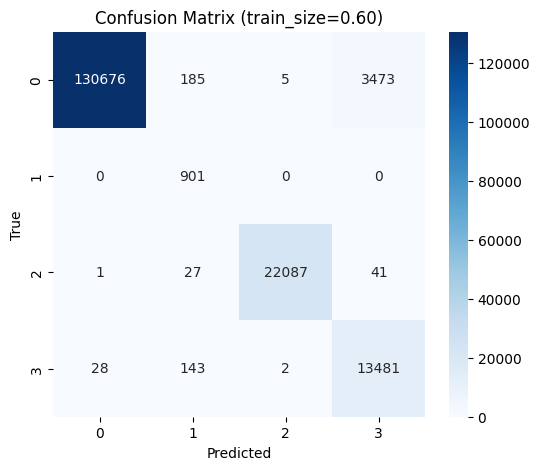

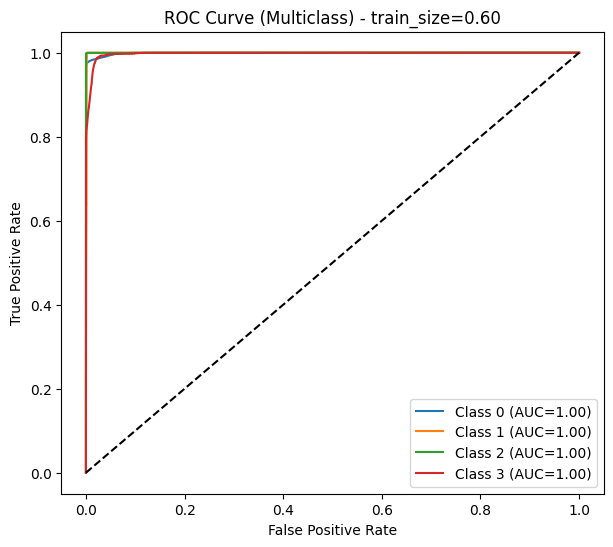


All done. Results keys: ['train_60']


In [12]:
# ---------------------------
# Run for the three splits
# ---------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(device)

    splits = [0.6]  # same as earlier

    all_results = {}
    for s in splits:
        print("\n\n==============================")
        print(f" Running parallel CNN+LSTM | scaler={SCALER_NAME} | classifier={CLASSIFIER_TYPE} | imbalance={IMB_METHOD}")
        print(f" Train size = {s:.2f} (train/test = {s:.0%}/{(1-s):.0%})")
        print("==============================\n")

        res = run_for_split(X, y, train_size=s, seed=SEED, device=device)
        all_results[f"train_{int(s*100)}"] = res

    # Optional save
    # import json
    # with open(f"results_{SCALER_NAME}_{CLASSIFIER_TYPE}_{IMB_METHOD}.json","w") as f:
    #     json.dump(all_results, f, default=lambda o: o.tolist() if isinstance(o, np.ndarray) else o)

    print("\nAll done. Results keys:", list(all_results.keys()))


cpu


 Running pipeline | scaler=minmax | classifier=softmax | imbalance=smote
 Train size = 0.70 (train/test = 70%/30%)

After resampling (SMOTE): class counts: {0: 235092, 2: 235092, 3: 235092, 1: 235092}
Epoch 1/10 - train_loss: 0.2675, test_acc: 0.9227
Epoch 2/10 - train_loss: 0.0991, test_acc: 0.9709
Epoch 3/10 - train_loss: 0.0663, test_acc: 0.9690
Epoch 4/10 - train_loss: 0.0536, test_acc: 0.9731
Epoch 5/10 - train_loss: 0.0560, test_acc: 0.9701
Epoch 6/10 - train_loss: 0.0457, test_acc: 0.9756
Epoch 7/10 - train_loss: 0.0458, test_acc: 0.9755
Epoch 8/10 - train_loss: 0.0438, test_acc: 0.9717
Epoch 9/10 - train_loss: 0.0426, test_acc: 0.9806
Epoch 10/10 - train_loss: 0.0394, test_acc: 0.9808

===== Evaluation Results =====
accuracy: 0.9808
precision: 0.9001
recall: 0.9900
f1_macro: 0.9398
roc_auc: 0.9992
confusion_matrix: [[98501, 54, 1, 2199], [0, 676, 0, 0], [3, 22, 16557, 35], [20, 112, 11, 10097]]...
runtime_sec: 10740.8172
ram_used_mb: 330.3945
y_true: [0 0 3 ... 2 0 0]...


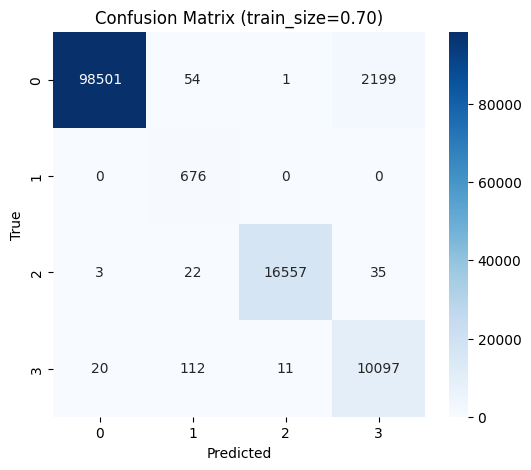

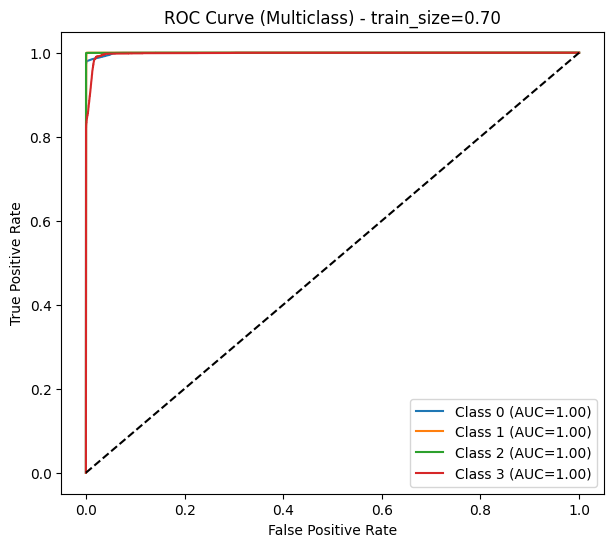


All done. Results keys: ['train_70']


In [13]:
# ---------------------------
# Run for the three splits
# ---------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(device)

    splits = [0.7]  # unchanged

    all_results = {}
    for s in splits:
        print("\n\n==============================")
        print(f" Running pipeline | scaler={SCALER_NAME} | classifier={CLASSIFIER_TYPE} | imbalance={IMB_METHOD}")
        print(f" Train size = {s:.2f} (train/test = {s:.0%}/{(1-s):.0%})")
        print("==============================\n")

        res = run_for_split(X, y, train_size=s, seed=SEED, device=device)
        all_results[f"train_{int(s*100)}"] = res

    # Optionally: save results
    # import json
    # with open(f"pipeline_results_{SCALER_NAME}_{CLASSIFIER_TYPE}_{IMB_METHOD}.json","w") as f:
    #     json.dump(all_results, f, default=lambda o: o.tolist() if isinstance(o, np.ndarray) else o)

    print("\nAll done. Results keys:", list(all_results.keys()))


cpu


 Running pipeline | scaler=minmax | classifier=softmax | imbalance=smote
 Train size = 0.80 (train/test = 80%/20%)

After resampling (SMOTE): class counts: {3: 268678, 0: 268678, 2: 268678, 1: 268678}
Epoch 1/10 - train_loss: 0.2596, test_acc: 0.9234
Epoch 2/10 - train_loss: 0.1189, test_acc: 0.9474
Epoch 3/10 - train_loss: 0.0837, test_acc: 0.9740
Epoch 4/10 - train_loss: 0.0646, test_acc: 0.9734
Epoch 5/10 - train_loss: 0.0535, test_acc: 0.9706
Epoch 6/10 - train_loss: 0.0464, test_acc: 0.9717
Epoch 7/10 - train_loss: 0.0423, test_acc: 0.9799
Epoch 8/10 - train_loss: 0.0403, test_acc: 0.9763
Epoch 9/10 - train_loss: 0.0479, test_acc: 0.9704
Epoch 10/10 - train_loss: 0.0473, test_acc: 0.9730

===== Evaluation Results =====
accuracy: 0.9730
precision: 0.8676
recall: 0.9873
f1_macro: 0.9176
roc_auc: 0.9991
confusion_matrix: [[64988, 95, 0, 2086], [0, 450, 0, 1], [0, 15, 11032, 31], [6, 74, 2, 6745]]...
runtime_sec: 1148.4489
ram_used_mb: 758.0391
y_true: [0 0 0 ... 0 0 3]...
y_pro

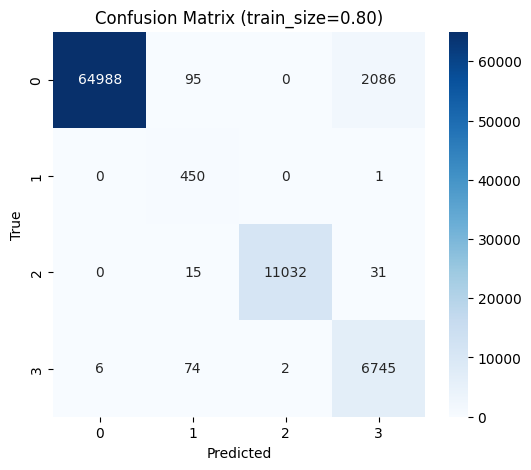

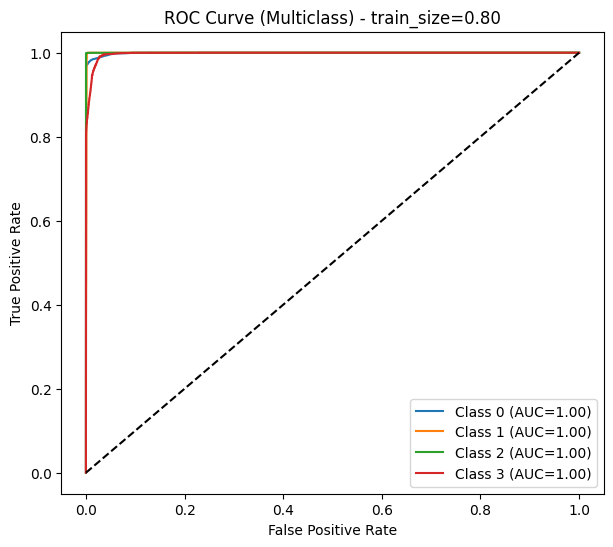


All done. Results keys: ['train_80']


In [14]:
# ---------------------------
# Run for the three splits
# ---------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(device)

    splits = [0.8]  # unchanged

    all_results = {}
    for s in splits:
        print("\n\n==============================")
        print(f" Running pipeline | scaler={SCALER_NAME} | classifier={CLASSIFIER_TYPE} | imbalance={IMB_METHOD}")
        print(f" Train size = {s:.2f} (train/test = {s:.0%}/{(1-s):.0%})")
        print("==============================\n")

        res = run_for_split(X, y, train_size=s, seed=SEED, device=device)
        all_results[f"train_{int(s*100)}"] = res

    # Optionally: save results
    # import json
    # with open(f"pipeline_results_{SCALER_NAME}_{CLASSIFIER_TYPE}_{IMB_METHOD}.json","w") as f:
    #     json.dump(all_results, f, default=lambda o: o.tolist() if isinstance(o, np.ndarray) else o)

    print("\nAll done. Results keys:", list(all_results.keys()))
